# Collect Results for Paper Figures

This notebook is a paper-facing analysis notebook for the Sachs benchmark slice.

It assumes the following files already exist under `experiments/responses/sachs/`:
- `sachs_summary.csv`

The notebook has four analysis sections:
1. **Main comparison tables** — clean paper cohort, representation sensitivity, semantic-prior audit
2. **Main paper figures** — classical-vs-LLM bar charts (F1 / SHD by setting) and data-budget curves
3. **Valid response rate** — heatmap of parse success by prompt configuration (pretrained LLMs only)
4. **Qwen / GRPO comparison** — pretrained vs fine-tuned Qwen variants on shared Sachs conditions

Set `OBS_N` / `INT_N` in section 2 to switch the data slice for the bar charts.
The main paper analysis uses `avg_*` metrics rather than consensus metrics.
All figures are saved under `experiments/responses/sachs/paper_figures/`.

In [9]:
%config InlineBackend.figure_format = 'svg'

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

# ── Path resolution ────────────────────────────────────────────────────────────
REPO_ROOT = Path.cwd().parent
if REPO_ROOT.name == 'experiments' and not (REPO_ROOT / 'responses').exists():
    REPO_ROOT = REPO_ROOT.parent
elif not (REPO_ROOT / 'experiments').exists() and (REPO_ROOT.parent / 'experiments').exists():
    REPO_ROOT = REPO_ROOT.parent

GRAPH_NAME    = 'sachs'
RESPONSES_DIR = REPO_ROOT / 'experiments' / 'responses' / GRAPH_NAME
RAW_SUMMARY_CSV = RESPONSES_DIR / f'{GRAPH_NAME}_summary.csv'
SCRIPTS_SUMMARY_CSV = REPO_ROOT / 'scripts' / 'responses' / GRAPH_NAME / f'{GRAPH_NAME}_summary.csv'
MAIN_COHORT_CSV = RESPONSES_DIR / 'sachs_main_cohort.csv'
FIG_DIR   = RESPONSES_DIR / 'paper_figures'
TABLE_DIR = RESPONSES_DIR / 'paper_tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# ── NeurIPS figure style ───────────────────────────────────────────────────────
FONT_SIZE   = 8      # axis labels
TICK_SIZE   = 7      # tick labels
LEGEND_SIZE = 7
LW          = 1.2    # default line width
COL1_W      = 3.25   # single-column figure width (inches)
COL2_W      = 6.75   # double-column figure width (inches)
FIG_H       = 2.4    # standard panel height

mpl.rcParams.update({
    'font.family':        'sans-serif',
    'font.size':          FONT_SIZE,
    'axes.labelsize':     FONT_SIZE,
    'axes.titlesize':     FONT_SIZE,
    'xtick.labelsize':    TICK_SIZE,
    'ytick.labelsize':    TICK_SIZE,
    'legend.fontsize':    LEGEND_SIZE,
    'legend.framealpha':  0.85,
    'legend.edgecolor':   '0.8',
    'lines.linewidth':    LW,
    'axes.linewidth':     0.6,
    'xtick.major.width':  0.6,
    'ytick.major.width':  0.6,
    'grid.linewidth':     0.4,
    'grid.alpha':         0.4,
    'figure.dpi':         150,       # screen preview; savefig overrides to 300
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'savefig.pad_inches': 0.02,
})

sns.set_style('ticks')

# Okabe-Ito colorblind-safe palette (via seaborn 'colorblind')
PALETTE_CB = sns.color_palette('colorblind')

SETTING_LABELS = {
    'name only':     'Names only',
    'names_only':    'Names only',
    'summary':       'Summary',
    'summary_joint': 'Summary',
    'matrix':        'Matrix',
    'ENCO':          'ENCO',
}

def save_fig(fig, stem, formats=('pdf', 'png')):
    """Save figure under FIG_DIR in each requested format."""
    for fmt in formats:
        out = FIG_DIR / f'{stem}.{fmt}'
        fig.savefig(out, format=fmt)
    print(f'Saved → {stem}')

In [10]:
parts = [pd.read_csv(RAW_SUMMARY_CSV)]
if SCRIPTS_SUMMARY_CSV.exists():
    parts.append(pd.read_csv(SCRIPTS_SUMMARY_CSV))
raw_summary = pd.concat(parts, ignore_index=True).drop_duplicates()

plot_src = raw_summary.copy()
plot_src['prompt_style_norm'] = plot_src['prompt_style'].replace({'summary': 'summary_joint'})
main = pd.read_csv(MAIN_COHORT_CSV)

print('Raw summary:', raw_summary.shape)
print('Main cohort:', main.shape)

display(main.sort_values(['obs_n', 'int_n', 'system_kind', 'system', 'prompt_style', 'naming_regime']).reset_index(drop=True))

Raw summary: (1073, 230)
Main cohort: (36, 18)


,dataset,system,system_kind,model,prompt_style,naming_regime,obs_n,int_n,consensus_f1,consensus_shd,consensus_precision,consensus_recall,consensus_accuracy,avg_f1,avg_shd,valid_rows,num_rows,source_file
0,sachs,gpt-5-mini,llm,gpt-5-mini,names_only,names_only,0,0,0.500000,14.0,0.636364,0.411765,0.872727,0.496322,14.6,5,5,responses_names_only_p5_gpt-5-mini.csv
1,sachs,ENCO,classical,ENCO,classical,real,0,50,0.102564,35.0,0.090909,0.117647,0.681818,0.102564,35.0,1,1,predictions_obs0_int50_ENCO.csv
2,sachs,ENCO,classical,ENCO,classical,real,0,100,0.136364,38.0,0.111111,0.176471,0.654545,0.136364,38.0,1,1,predictions_obs0_int100_ENCO.csv
3,sachs,gpt-5-mini,llm,gpt-5-mini,matrix,anonymized,0,100,0.190476,17.0,0.500000,0.117647,0.845455,0.257781,20.8,5,5,responses_obs0_int100_shuf1_p5_anon_matrix_gpt...
4,sachs,gpt-5-mini,llm,gpt-5-mini,matrix,real,0,100,0.320000,17.0,0.500000,0.235294,0.845455,0.424849,16.2,5,5,responses_obs0_int100_shuf1_p5_matrix_gpt-5-mi...
5,sachs,gpt-5-mini,llm,gpt-5-mini,summary,anonymized,0,100,NaN,17.0,NaN,0.000000,0.845455,0.356080,53.8,5,5,responses_obs0_int100_shuf1_p5_anon_summary_gp...
6,sachs,gpt-5-mini,llm,gpt-5-mini,summary,real,0,100,0.424242,19.0,0.437500,0.411765,0.827273,0.431748,22.6,5,5,responses_obs0_int100_shuf1_p5_summary_gpt-5-m...
7,sachs,ENCO,classical,ENCO,classical,real,0,200,0.133333,39.0,0.107143,0.176471,0.645455,0.133333,39.0,1,1,predictions_obs0_int200_ENCO.csv
8,sachs,gpt-5-mini,llm,gpt-5-mini,matrix,anonymized,0,200,0.095238,19.0,0.250000,0.058824,0.827273,0.296713,19.2,5,5,responses_obs0_int200_shuf1_p5_anon_matrix_gpt...
9,sachs,gpt-5-mini,llm,gpt-5-mini,matrix,real,0,200,0.250000,18.0,0.428571,0.176471,0.836364,0.415344,16.4,5,5,responses_obs0_int200_shuf1_p5_matrix_gpt-5-mi...


## Main comparison tables

These tables are the paper-facing views for Sachs. The main analysis uses `avg_f1` and `avg_shd`.


In [11]:
main_table = main[[
    'system', 'system_kind', 'prompt_style', 'naming_regime',
    'obs_n', 'int_n', 'avg_f1', 'avg_shd', 'valid_rows', 'num_rows', 'source_file'
]].sort_values(['obs_n', 'int_n', 'system_kind', 'system', 'prompt_style', 'naming_regime']).reset_index(drop=True)

display(main_table)


,system,system_kind,prompt_style,naming_regime,obs_n,int_n,avg_f1,avg_shd,valid_rows,num_rows,source_file
0,gpt-5-mini,llm,names_only,names_only,0,0,0.496322,14.6,5,5,responses_names_only_p5_gpt-5-mini.csv
1,ENCO,classical,classical,real,0,50,0.102564,35.0,1,1,predictions_obs0_int50_ENCO.csv
2,ENCO,classical,classical,real,0,100,0.136364,38.0,1,1,predictions_obs0_int100_ENCO.csv
3,gpt-5-mini,llm,matrix,anonymized,0,100,0.257781,20.8,5,5,responses_obs0_int100_shuf1_p5_anon_matrix_gpt...
4,gpt-5-mini,llm,matrix,real,0,100,0.424849,16.2,5,5,responses_obs0_int100_shuf1_p5_matrix_gpt-5-mi...
5,gpt-5-mini,llm,summary,anonymized,0,100,0.356080,53.8,5,5,responses_obs0_int100_shuf1_p5_anon_summary_gp...
6,gpt-5-mini,llm,summary,real,0,100,0.431748,22.6,5,5,responses_obs0_int100_shuf1_p5_summary_gpt-5-m...
7,ENCO,classical,classical,real,0,200,0.133333,39.0,1,1,predictions_obs0_int200_ENCO.csv
8,gpt-5-mini,llm,matrix,anonymized,0,200,0.296713,19.2,5,5,responses_obs0_int200_shuf1_p5_anon_matrix_gpt...
9,gpt-5-mini,llm,matrix,real,0,200,0.415344,16.4,5,5,responses_obs0_int200_shuf1_p5_matrix_gpt-5-mi...


In [12]:
repr_table = (
    main[
        (main['system'] == 'gpt-5-mini')
        & (main['prompt_style'].isin(['summary', 'matrix']))  # 'summary' is pre-refactor name
    ]
    .pivot_table(
        index=['obs_n', 'int_n', 'naming_regime'],
        columns='prompt_style',
        values=['avg_f1', 'avg_shd'],
        aggfunc='first',
    )
    .sort_index()
)

repr_table

avg_f1           avg_shd        
prompt_style                 matrix   summary  matrix summary
obs_n int_n naming_regime                                    
0     100   anonymized     0.257781  0.356080    20.8    53.8
            real           0.424849  0.431748    16.2    22.6
      200   anonymized     0.296713  0.422158    19.2    40.0
            real           0.415344  0.413266    16.4    25.0

In [13]:
AUDIT_PROMPT = 'summary'  # pre-refactor name in sachs_main_cohort.csv

full_info = main[
    (main['system'] == 'gpt-5-mini')
    & (main['prompt_style'] == AUDIT_PROMPT)
].copy()

names_only = main[
    (main['system'] == 'gpt-5-mini')
    & (main['prompt_style'] == 'names_only')
].copy()

if names_only.empty:
    raise ValueError('No names_only row found in main cohort.')

names_only_row = names_only.iloc[0]
real = full_info[full_info['naming_regime'] == 'real'].copy()
anon = full_info[full_info['naming_regime'] == 'anonymized'].copy()

semantic_audit = real.merge(
    anon,
    on=['obs_n', 'int_n', 'prompt_style', 'system', 'system_kind'],
    suffixes=('_real', '_anon'),
)
semantic_audit['names_only_f1']  = float(names_only_row['avg_f1'])
semantic_audit['names_only_shd'] = float(names_only_row['avg_shd'])
semantic_audit['real_minus_anon_f1']        = semantic_audit['avg_f1_real'] - semantic_audit['avg_f1_anon']
semantic_audit['real_minus_names_only_f1']  = semantic_audit['avg_f1_real'] - semantic_audit['names_only_f1']
semantic_audit['anon_minus_names_only_f1']  = semantic_audit['avg_f1_anon'] - semantic_audit['names_only_f1']
semantic_audit['anon_minus_real_shd']       = semantic_audit['avg_shd_anon'] - semantic_audit['avg_shd_real']
semantic_audit = semantic_audit[[
    'obs_n', 'int_n',
    'avg_f1_real', 'avg_f1_anon', 'names_only_f1',
    'real_minus_anon_f1', 'real_minus_names_only_f1', 'anon_minus_names_only_f1',
    'avg_shd_real', 'avg_shd_anon', 'names_only_shd', 'anon_minus_real_shd',
]].sort_values(['obs_n', 'int_n'])

semantic_audit

,obs_n,int_n,avg_f1_real,avg_f1_anon,names_only_f1,real_minus_anon_f1,real_minus_names_only_f1,anon_minus_names_only_f1,avg_shd_real,avg_shd_anon,names_only_shd,anon_minus_real_shd
0,0,100,0.431748,0.356080,0.496322,0.075668,-0.064573,-0.140241,22.6,53.8,14.6,31.2
1,0,200,0.413266,0.422158,0.496322,-0.008891,-0.083055,-0.074164,25.0,40.0,14.6,15.0


## Main paper figures

The figures below correspond to the main benchmark story:
- representation sensitivity,
- semantic-prior audit,
- classical-vs-LLM budget curves.


Saved → sachs_budget_curve_obs100_avg_f1


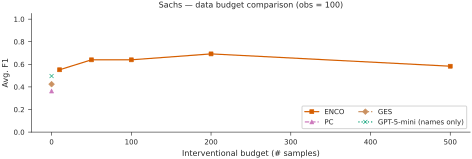

In [14]:
# ── Build curve data ──────────────────────────────────────────────────────────
# sachs_main_cohort uses 'summary' (pre-refactor); filter accordingly
curve_df = main[main['system'].isin(['ENCO', 'PC', 'GES', 'gpt-5-mini'])].copy()
curve_df = curve_df[
    (curve_df['prompt_style'].isin(['classical', 'summary']))
    | ((curve_df['system'] == 'gpt-5-mini') & (curve_df['prompt_style'] == 'names_only'))
].copy()
curve_df['display_system'] = curve_df.apply(
    lambda r: r['system'] if r['system_kind'] == 'classical'
    else ('GPT-5-mini (summary)' if r['prompt_style'] == 'summary'
          else 'GPT-5-mini (names only)'),
    axis=1,
)

obs_focus  = 100
plot_curve = curve_df[
    (curve_df['obs_n'] == obs_focus) | (curve_df['prompt_style'] == 'names_only')
].copy()
plot_curve.loc[plot_curve['prompt_style'] == 'names_only', 'int_n'] = 0

# ── Visual encoding: color + marker + linestyle per system ────────────────────
SYS_STYLE = {
    'ENCO':                    dict(color=PALETTE_CB[3], marker='s',  ls='-'),
    'PC':                      dict(color=PALETTE_CB[4], marker='^',  ls='--'),
    'GES':                     dict(color=PALETTE_CB[5], marker='D',  ls='-.'),
    'GPT-5-mini (summary)':    dict(color=PALETTE_CB[0], marker='o',  ls='-'),
    'GPT-5-mini (names only)': dict(color=PALETTE_CB[2], marker='x',  ls=':'),
}

fig, ax = plt.subplots(figsize=(COL2_W, FIG_H))

for sys, style in SYS_STYLE.items():
    sub = plot_curve[plot_curve['display_system'] == sys].sort_values('int_n')
    if sub.empty:
        continue
    ax.plot(sub['int_n'], sub['avg_f1'], label=sys,
            markersize=4, markeredgewidth=0.6, **style)

ax.set_xlabel('Interventional budget (# samples)')
ax.set_ylabel('Avg. F1')
ax.set_title(f'Sachs — data budget comparison (obs = {obs_focus})')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
ax.legend(ncol=2, loc='lower right')
sns.despine(ax=ax)
fig.tight_layout()

save_fig(fig, f'sachs_budget_curve_obs{obs_focus}_avg_f1')
plt.show()

In [15]:
# ── Change these two to switch the data slice ──────────────────────────────────
OBS_N = 5000
INT_N = 200

# ── Model display names — edit this dict to add / remove models ───────────────
PRETTY_MODEL = {
    'GES':                     'GES',
    'PC':                      'PC',
    'ENCO':                    'ENCO',
    'gpt-5-mini':              'GPT-5-mini',
    'gpt-5.2-pro':             'GPT-5.2-pro',
    'Qwen3-4B-Thinking-2507':  'Qwen3-4B (base)',
    'Qwen2.5-14B-Instruct':    'Qwen2.5-14B',
    'Qwen2.5-72B-Instruct-AWQ': 'Qwen2.5-72B',
    'checkpoint-300_merged_vllm':                             'Ckpt-300 (merged)',
    'checkpoint-400':                                         'Ckpt-400',
    'qwen3_4b_sft_5way_v4_2gpu_merged':                       'SFT-5way-v4',
    'qwen3_4b_cd_format_v5_rerun_2gpu':                       'CD-v5',
    'qwen3_4b_cd_format_v5_rerun_2gpu_checkpoint-100':        'CD-v5 Ckpt-100',
    'qwen3_4b_cd_format_v5_rerun_2gpu_checkpoint-300_merged': 'CD-v5 Ckpt-300',
    'grpo_from_qwen3_4b_sft_5way_v4_2gpu_checkpoint-100_merged': 'GRPO Ckpt-100',
    'grpo_from_qwen3_4b_sft_5way_v4_2gpu_checkpoint-400':        'GRPO Ckpt-400',
}

# Restrict to models that have at least one row with valid_rows > 0 in plot_src
active_models = set(plot_src[plot_src['valid_rows'].fillna(0) > 0]['model'].dropna())
active_pretty = {k: v for k, v in PRETTY_MODEL.items() if k in active_models}
model_order = list(active_pretty.values())

real_setting_order = ['name only', 'summary_joint', 'matrix', 'ENCO']
anon_setting_order = ['summary_joint', 'matrix', 'ENCO']

# ── Full-information slice ─────────────────────────────────────────────────────
llm_full_info = plot_src[
    plot_src['model'].isin([m for m in active_pretty if m not in ('ENCO', 'GES', 'PC')])
    & (plot_src['obs_n'].fillna(-1) == OBS_N)
    & (plot_src['int_n'].fillna(-1) == INT_N)
    & (plot_src['prompt_style_norm'].isin(['summary_joint', 'matrix']))
    & (plot_src['valid_rows'].fillna(0) > 0)
].copy()

classical_full_info = plot_src[
    plot_src['model'].isin(['GES', 'PC', 'ENCO'])
    & (plot_src['obs_n'].fillna(-1) == OBS_N)
    & (plot_src['int_n'].fillna(-1) == INT_N)
    & (plot_src['prompt_style_norm'] == 'baseline')
].copy()

full_info = pd.concat([llm_full_info, classical_full_info], ignore_index=True)
full_info['display_model'] = full_info['model'].map(active_pretty)
full_info = full_info[full_info['display_model'].notna()].copy()
full_info['setting'] = full_info['prompt_style_norm'].replace({'enco': 'ENCO'})
full_info.loc[full_info['model'].isin(['ENCO', 'GES', 'PC']), 'setting'] = 'ENCO'

# ── Names-only control ────────────────────────────────────────────────────────
name_only = plot_src[
    plot_src['model'].isin(active_pretty)
    & (plot_src['prompt_style_norm'] == 'names_only')
    & (plot_src['valid_rows'].fillna(0) > 0)
].copy()
name_only['display_model'] = name_only['model'].map(active_pretty)
name_only = name_only[name_only['display_model'].notna()].copy()
name_only['setting'] = 'name only'

for df in [full_info, name_only]:
    df['display_model'] = pd.Categorical(
        df['display_model'], categories=model_order, ordered=True
    )

print('Active models:', model_order)
# display(
#     full_info[[
#         'display_model', 'anonymize', 'setting',
#         'avg_f1', 'avg_f1_sd', 'avg_shd', 'avg_shd_sd', 'valid_rows',
#     ]].sort_values(['display_model', 'anonymize', 'setting']).reset_index(drop=True)
# )

Active models: ['GES', 'PC', 'ENCO', 'GPT-5-mini', 'GPT-5.2-pro', 'Qwen3-4B (base)', 'Qwen2.5-14B', 'Qwen2.5-72B', 'Ckpt-300 (merged)', 'SFT-5way-v4', 'CD-v5', 'CD-v5 Ckpt-100', 'CD-v5 Ckpt-300', 'GRPO Ckpt-100', 'GRPO Ckpt-400']


Saved → sachs_obs5000_int200_f1_comparison


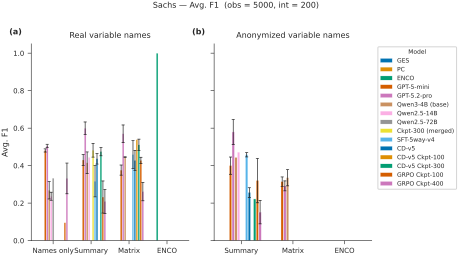

Saved → sachs_obs5000_int200_shd_comparison


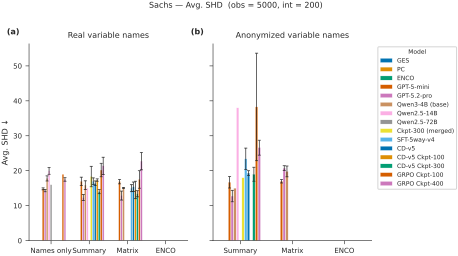

In [16]:
# ── Aggregate mean + SE for plotting ──────────────────────────────────────────
PLOT_METRICS = ['avg_f1', 'avg_f1_sd', 'avg_shd', 'avg_shd_sd', 'valid_rows']

def build_plot_df(src, setting_order, model_order):
    """Collapse to one row per (model, setting); propagate SE for error bars."""
    df = src[['display_model', 'setting'] + PLOT_METRICS].copy()
    for c in PLOT_METRICS:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = (
        df.groupby(['display_model', 'setting'], observed=True)
        .agg(**{c: (c, 'mean') for c in PLOT_METRICS})
        .reset_index()
    )
    n = df['valid_rows'].clip(lower=1)
    df['f1_se']  = df['avg_f1_sd']  / n.pow(0.5)
    df['shd_se'] = df['avg_shd_sd'] / n.pow(0.5)
    df['display_model'] = pd.Categorical(
        df['display_model'], categories=model_order, ordered=True)
    df['setting'] = pd.Categorical(
        df['setting'], categories=setting_order, ordered=True)
    return df

real_src = pd.concat(
    [full_info[full_info['anonymize'].fillna(0).astype(int) == 0], name_only],
    ignore_index=True,
)
anon_src = full_info[full_info['anonymize'].fillna(0).astype(int) == 1].copy()

real_df = build_plot_df(real_src, real_setting_order, model_order)
anon_df = build_plot_df(anon_src, anon_setting_order, model_order)

# One color per model, reused across all figures
palette     = sns.color_palette('colorblind', n_colors=len(model_order))
model_color = dict(zip(model_order, palette))

# ── Grouped bar + ±1 SE error-cap helper ──────────────────────────────────────
def draw_grouped_bars(ax, df, metric, err_col, setting_order, model_order,
                      model_color, ylabel=None, title=None,
                      panel_label=None, show_legend=False):
    n_s     = len(setting_order)
    n_m     = len(model_order)
    width   = 0.78 / n_m
    offsets = np.linspace(-(n_m - 1) / 2, (n_m - 1) / 2, n_m) * width
    x = np.arange(n_s)

    for i, model in enumerate(model_order):
        sub  = (df[df['display_model'] == model]
                .set_index('setting')
                .reindex(setting_order))
        vals = sub[metric].values
        errs = sub[err_col].fillna(0).values

        ax.bar(x + offsets[i],
               np.where(np.isnan(vals), 0, vals),
               width=width * 0.9,
               color=model_color[model],
               label=model,
               edgecolor='white', linewidth=0.3)

        for j, (v, e) in enumerate(zip(vals, errs)):
            if not np.isnan(v) and e > 0:
                ax.errorbar(x[j] + offsets[i], v, yerr=e,
                            fmt='none', color='#222222',
                            elinewidth=0.7, capsize=1.5, capthick=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels([SETTING_LABELS.get(s, s) for s in setting_order])
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    if panel_label:
        ax.text(-0.14, 1.04, panel_label, transform=ax.transAxes,
                fontsize=FONT_SIZE, fontweight='bold', va='bottom')
    if show_legend:
        fig = ax.get_figure()
        handles, labels = ax.get_legend_handles_labels()
        right_ax = fig.get_axes()[-1]
        fig.legend(handles, labels,
                   title='Model', ncol=1,
                   fontsize=LEGEND_SIZE - 1, title_fontsize=LEGEND_SIZE - 1,
                   loc='upper left',
                   bbox_to_anchor=(1.02, 1),
                   bbox_transform=right_ax.transAxes)
    sns.despine(ax=ax)

slice_label = f'obs = {OBS_N}, int = {INT_N}'
fig_stem    = f'sachs_obs{OBS_N}_int{INT_N}'

# ── Figure 1: Avg. F1 (real | anonymized) ─────────────────────────────────────
fig_f1, axes = plt.subplots(1, 2, figsize=(COL2_W, FIG_H * 1.5), sharey=True)

draw_grouped_bars(axes[0], real_df, 'avg_f1', 'f1_se',
                  real_setting_order, model_order, model_color,
                  ylabel='Avg. F1', title='Real variable names',
                  panel_label='(a)', show_legend=True)
axes[0].set_ylim(0, 1.05)

draw_grouped_bars(axes[1], anon_df, 'avg_f1', 'f1_se',
                  anon_setting_order, model_order, model_color,
                  title='Anonymized variable names',
                  panel_label='(b)')
axes[1].set_ylim(0, 1.05)

fig_f1.suptitle(f'Sachs — Avg. F1  ({slice_label})', fontsize=FONT_SIZE, y=1.01)
fig_f1.tight_layout()
fig_f1.subplots_adjust(right=0.78)
save_fig(fig_f1, f'{fig_stem}_f1_comparison')
plt.show()

# ── Figure 2: Avg. SHD (real | anonymized) ────────────────────────────────────
fig_shd, axes = plt.subplots(1, 2, figsize=(COL2_W, FIG_H * 1.5), sharey=True)

draw_grouped_bars(axes[0], real_df, 'avg_shd', 'shd_se',
                  real_setting_order, model_order, model_color,
                  ylabel='Avg. SHD ↓', title='Real variable names',
                  panel_label='(a)', show_legend=True)

draw_grouped_bars(axes[1], anon_df, 'avg_shd', 'shd_se',
                  anon_setting_order, model_order, model_color,
                  title='Anonymized variable names',
                  panel_label='(b)')

fig_shd.suptitle(f'Sachs — Avg. SHD  ({slice_label})', fontsize=FONT_SIZE, y=1.01)
fig_shd.tight_layout()
fig_shd.subplots_adjust(right=0.78)
save_fig(fig_shd, f'{fig_stem}_shd_comparison')
plt.show()

In [17]:
df = pd.read_csv("/home/yuen_chen/ENCO/scripts/responses/sachs/sachs_summary.csv")

In [18]:
# ── Model ranking — scripts/responses/sachs/sachs_summary.csv ─────────────────
_df = pd.read_csv(SCRIPTS_SUMMARY_CSV)
_valid = _df[_df['valid_rows'].fillna(0) > 0].copy()

RANK_PRETTY = {
    'Qwen3-4B-Thinking-2507':                                'Qwen3-4B (base)',
    'qwen3_4b_sft_5way_v4_2gpu_merged':                      'SFT-5way-v4',
    'qwen3_4b_cd_format_v5_rerun_2gpu':                      'CD-v5',
    'qwen3_4b_cd_format_v5_rerun_2gpu_checkpoint-100':       'CD-v5 Ckpt-100',
    'qwen3_4b_cd_format_v5_rerun_2gpu_checkpoint-300_merged':'CD-v5 Ckpt-300',
    'grpo_from_qwen3_4b_sft_5way_v4_2gpu_checkpoint-100_merged': 'GRPO Ckpt-100',
    'grpo_from_qwen3_4b_sft_5way_v4_2gpu_checkpoint-400':        'GRPO Ckpt-400',
}
_valid['display_model'] = _valid['model'].map(RANK_PRETTY).fillna(_valid['model'])

def _condition(row):
    if row['prompt_style'] == 'names_only':
        return 'name_only'
    return 'anonymized' if row['anonymize'] == 1 else 'withdata'

_valid['condition'] = _valid.apply(_condition, axis=1)

# ── Shared configs: conditions where every model has at least one valid result ──
_config_cols = ['obs_n', 'int_n', 'prompt_style', 'anonymize']
_n_models = _valid['model'].nunique()
_shared_cfgs = (
    _valid.groupby(_config_cols)['model'].nunique()
    .reset_index(name='n_models')
    .query('n_models == @_n_models')[_config_cols]
    .reset_index(drop=True)
)
_shared = _valid.merge(_shared_cfgs, on=_config_cols)

# ── Weighted mean: weight each row by its valid_rows count ─────────────────────
def _wmean(g, val_col, wt_col='valid_rows'):
    w = g[wt_col].clip(lower=1)
    return (g[val_col] * w).sum() / w.sum()

# ── Table 1: Overall ranking on shared configs ─────────────────────────────────
_rank = (
    _shared.groupby('display_model')
    .apply(lambda g: pd.Series({
        'F1 (wtd mean)':  round(_wmean(g, 'avg_f1'), 3),
        'SHD (wtd mean)': round(_wmean(g, 'avg_shd'), 1),
        'configs':        len(g),
        'total valid':    int(g['valid_rows'].sum()),
    }), include_groups=False)
    .sort_values(['F1 (wtd mean)', 'SHD (wtd mean)'], ascending=[False, True])
    .reset_index()
    .rename(columns={'display_model': 'Model'})
)
_rank.insert(0, 'Rank', range(1, len(_rank) + 1))

print(f'── Table 1: Overall ranking — shared configs ({_n_models} models, {len(_shared_cfgs)} conditions) ──')
display(_rank)
print(f'\nShared conditions:')
display(_shared_cfgs)

# ── Table 2: Per-condition breakdown ──────────────────────────────────────────
_cond_long = (
    _valid.groupby(['display_model', 'condition'])
    .apply(lambda g: pd.Series({
        'F1':         round(_wmean(g, 'avg_f1'), 3),
        'SHD':        round(_wmean(g, 'avg_shd'), 1),
    }), include_groups=False)
    .reset_index()
)
_cond_wide = _cond_long.pivot_table(
    index='display_model', columns='condition', values=['F1', 'SHD'], aggfunc='first'
)
_cond_wide.columns = [f'{m} ({c})' for m, c in _cond_wide.columns]
_cond_order = ['name_only', 'withdata', 'anonymized']
_f1_cols  = [f'F1 ({c})'  for c in _cond_order if f'F1 ({c})'  in _cond_wide.columns]
_shd_cols = [f'SHD ({c})' for c in _cond_order if f'SHD ({c})' in _cond_wide.columns]
_cond_wide = (
    _cond_wide[_f1_cols + _shd_cols]
    .sort_values(_f1_cols[1] if len(_f1_cols) > 1 else _f1_cols[0], ascending=False)
    .reset_index()
    .rename(columns={'display_model': 'Model'})
)
_cond_wide.insert(0, 'Rank', range(1, len(_cond_wide) + 1))

print('\n── Table 2: Per-condition breakdown — wtd-mean F1 (↑) and SHD (↓) ──')
display(_cond_wide)

# ── Table 3: Semantic-prior lift (real − anonymized) ──────────────────────────
if 'F1 (withdata)' in _cond_wide.columns and 'F1 (anonymized)' in _cond_wide.columns:
    _lift = _cond_wide[['Model', 'F1 (withdata)', 'F1 (anonymized)']].copy()
    _lift['F1 lift (real − anon)'] = (_lift['F1 (withdata)'] - _lift['F1 (anonymized)']).round(3)
    _lift = _lift.sort_values('F1 lift (real − anon)', ascending=False).reset_index(drop=True)
    _lift.insert(0, 'Rank', range(1, len(_lift) + 1))
    print('\n── Table 3: Semantic-prior lift — F1(real names) − F1(anonymized) ──')
    display(_lift)

KeyError: 'F1 (wtd mean)'

## Valid response rate

How often did each model produce a parseable answer?  
`valid_rate = valid_rows / num_rows` aggregated (weighted sum) across all obs/int slices per condition.

In [ ]:

df['model'].unique()


array(['Qwen3-4B-Thinking-2507', 'qwen3_4b_sft_5way_v4_2gpu_merged',
       'qwen3_4b_sft_5way_v4_2gpu_checkpoint-200_merged',
       'qwen3_4b_cd_format_v5_rerun_2gpu_checkpoint-300_merged',
       'qwen3_4b_cd_format_v5_rerun_2gpu_checkpoint-100',
       'qwen3_4b_cd_format_v5_rerun_2gpu',
       'grpo_from_qwen3_4b_sft_5way_v4_ckpt200_free_probe_checkpoint-50_merged',
       'grpo_from_qwen3_4b_sft_5way_v4_2gpu_checkpoint-400',
       'grpo_from_qwen3_4b_sft_5way_v4_2gpu_checkpoint-100_merged',
       'grpo_from_qwen3_4b_sft_5way_v4_2gpu_checkpoint-100',
       'grpo_from_qwen3_4b_cd_format_v5_rerun_no_cancer_full_checkpoint-1600',
       'grpo_from_qwen3_4b_cd_format_v5_rerun_no_cancer_full_checkpoint-1200',
       'gpt-5-mini'], dtype=object)

Saved → sachs_all_models_by_prompt_type_f1


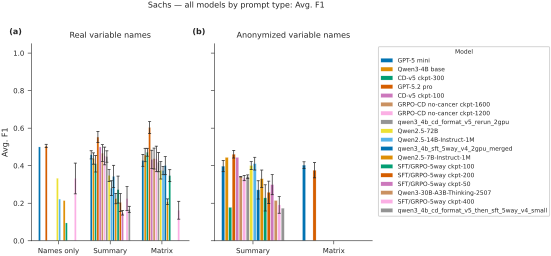

Saved → sachs_all_models_by_prompt_type_shd


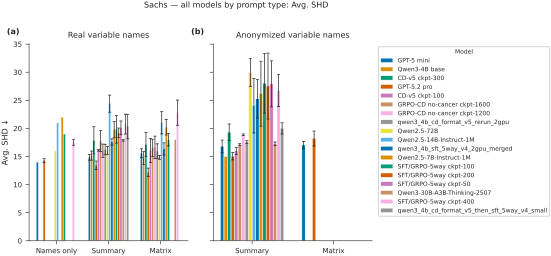

In [ ]:
import re

all_model_src = df[df['valid_rows'].fillna(0) > 0].copy()

ALL_MODEL_PRETTY = {
    'Qwen3-4B-Thinking-2507': 'Qwen3-4B base',
    'gpt-5-mini': 'GPT-5 mini',

    'qwen3_4b_sft_5way_v4_2gpu_merged': 'SFT-5way-v4 final',
    'qwen3_4b_sft_5way_v4_2gpu_checkpoint-200_merged': 'SFT-5way-v4 ckpt-200',

    'qwen3_4b_cd_format_v5_rerun_2gpu': 'CD-v5 final',
    'qwen3_4b_cd_format_v5_rerun_2gpu_checkpoint-100': 'CD-v5 ckpt-100',
    'qwen3_4b_cd_format_v5_rerun_2gpu_checkpoint-300_merged': 'CD-v5 ckpt-300',

    'grpo_from_qwen3_4b_sft_5way_v4_2gpu_checkpoint-100': 'GRPO-5way ckpt-100',
    'grpo_from_qwen3_4b_sft_5way_v4_2gpu_checkpoint-100_merged': 'GRPO-5way ckpt-100 merged',
    'grpo_from_qwen3_4b_sft_5way_v4_2gpu_checkpoint-400': 'GRPO-5way ckpt-400',

    'grpo_from_qwen3_4b_sft_5way_v4_ckpt200_free_probe_checkpoint-50_merged':
        'GRPO-free ckpt-50',

    'grpo_from_qwen3_4b_cd_format_v5_rerun_no_cancer_full_checkpoint-1200':
        'GRPO-CD no-cancer ckpt-1200',
    'grpo_from_qwen3_4b_cd_format_v5_rerun_no_cancer_full_checkpoint-1600':
        'GRPO-CD no-cancer ckpt-1600',
}

def pretty_model_name(m):
    if m in ALL_MODEL_PRETTY:
        return ALL_MODEL_PRETTY[m]

    # Fallback for future checkpoints.
    m2 = re.search(r'no_cancer_full_checkpoint-(\d+)', str(m))
    if m2:
        return f'GRPO-CD no-cancer ckpt-{m2.group(1)}'

    m2 = re.search(r'cd_format_v5_rerun_2gpu_checkpoint-(\d+)', str(m))
    if m2:
        return f'CD-v5 ckpt-{m2.group(1)}'

    m2 = re.search(r'sft_5way_v4.*checkpoint-(\d+)', str(m))
    if m2:
        return f'SFT/GRPO-5way ckpt-{m2.group(1)}'

    return str(m)

all_model_src['display_model'] = all_model_src['model'].map(pretty_model_name)
all_model_src['setting'] = all_model_src['prompt_style'].replace({'summary_joint': 'summary'})

real_setting_order = ['names_only', 'summary', 'matrix']
anon_setting_order = ['summary', 'matrix']

# Stable order: baselines -> SFTs -> GRPO variants -> anything new.
preferred_order = [
    'GPT-5 mini',
    'Qwen3-4B base',

    'SFT-5way-v4 ckpt-200',
    'SFT-5way-v4 final',

    'CD-v5 ckpt-100',
    'CD-v5 ckpt-300',
    'CD-v5 final',

    'GRPO-5way ckpt-100',
    'GRPO-5way ckpt-100 merged',
    'GRPO-5way ckpt-400',
    'GRPO-free ckpt-50',

    'GRPO-CD no-cancer ckpt-1200',
    'GRPO-CD no-cancer ckpt-1600',
]

present = all_model_src['display_model'].dropna().unique().tolist()
model_order = [m for m in preferred_order if m in present]

# Append any future/evaluated checkpoints not manually listed.
extra_models = [m for m in present if m not in model_order]
extra_models = sorted(
    extra_models,
    key=lambda m: all_model_src.loc[all_model_src['display_model'] == m, 'avg_f1'].mean(),
    reverse=True,
)
model_order += extra_models
# Rebuild plot inputs after final display_model/model_order are defined.
PLOT_METRICS = ['avg_f1', 'avg_f1_sd', 'avg_shd', 'avg_shd_sd', 'valid_rows']

def build_plot_df(src, setting_order, model_order):
    """Collapse to one row per (model, prompt type); propagate SE for error bars."""
    plot = src[['display_model', 'setting'] + PLOT_METRICS].copy()

    for c in PLOT_METRICS:
        plot[c] = pd.to_numeric(plot[c], errors='coerce')

    plot = (
        plot.groupby(['display_model', 'setting'], observed=True)
        .agg(**{c: (c, 'mean') for c in PLOT_METRICS})
        .reset_index()
    )

    n = plot['valid_rows'].clip(lower=1)
    plot['f1_se'] = plot['avg_f1_sd'] / n.pow(0.5)
    plot['shd_se'] = plot['avg_shd_sd'] / n.pow(0.5)

    plot['display_model'] = pd.Categorical(
        plot['display_model'],
        categories=model_order,
        ordered=True,
    )
    plot['setting'] = pd.Categorical(
        plot['setting'],
        categories=setting_order,
        ordered=True,
    )

    return plot.sort_values(['display_model', 'setting'])


real_src = all_model_src[all_model_src['anonymize'].fillna(0).astype(int) == 0].copy()
anon_src = all_model_src[all_model_src['anonymize'].fillna(0).astype(int) == 1].copy()

real_df = build_plot_df(real_src, real_setting_order, model_order)
anon_df = build_plot_df(anon_src, anon_setting_order, model_order)

# Must be after final model_order is complete.
palette = sns.color_palette('colorblind', n_colors=len(model_order))
model_color = dict(zip(model_order, palette))


def draw_grouped_bars(ax, plot, metric, err_col, setting_order, model_order,
                      model_color, ylabel=None, title=None,
                      panel_label=None, show_legend=False):
    n_s = len(setting_order)
    n_m = len(model_order)
    width = 0.78 / n_m
    offsets = np.linspace(-(n_m - 1) / 2, (n_m - 1) / 2, n_m) * width
    x = np.arange(n_s)

    for i, model in enumerate(model_order):
        sub = plot[plot['display_model'] == model].set_index('setting').reindex(setting_order)
        vals = sub[metric].values
        errs = sub[err_col].fillna(0).values

        ax.bar(x + offsets[i], np.where(np.isnan(vals), 0, vals),
               width=width * 0.9, color=model_color[model], label=model,
               edgecolor='white', linewidth=0.3)

        for j, (v, e) in enumerate(zip(vals, errs)):
            if not np.isnan(v) and e > 0:
                ax.errorbar(x[j] + offsets[i], v, yerr=e,
                            fmt='none', color='#222222',
                            elinewidth=0.7, capsize=1.5, capthick=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels([SETTING_LABELS.get(s, s) for s in setting_order])
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    if panel_label:
        ax.text(-0.14, 1.04, panel_label, transform=ax.transAxes,
                fontsize=FONT_SIZE, fontweight='bold', va='bottom')
    if show_legend:
        fig = ax.get_figure()
        handles, labels = ax.get_legend_handles_labels()
        right_ax = fig.get_axes()[-1]
        fig.legend(handles, labels, title='Model', ncol=1,
                   fontsize=LEGEND_SIZE - 1, title_fontsize=LEGEND_SIZE - 1,
                   loc='upper left', bbox_to_anchor=(1.02, 1),
                   bbox_transform=right_ax.transAxes)
    sns.despine(ax=ax)

fig_stem = 'sachs_all_models_by_prompt_type'

# ── Figure 1: Avg. F1 (real | anonymized) ─────────────────────────────────────
fig_f1, axes = plt.subplots(1, 2, figsize=(COL2_W, FIG_H * 1.5), sharey=True)

draw_grouped_bars(axes[0], real_df, 'avg_f1', 'f1_se',
                  real_setting_order, model_order, model_color,
                  ylabel='Avg. F1', title='Real variable names',
                  panel_label='(a)', show_legend=True)
axes[0].set_ylim(0, 1.05)

draw_grouped_bars(axes[1], anon_df, 'avg_f1', 'f1_se',
                  anon_setting_order, model_order, model_color,
                  title='Anonymized variable names', panel_label='(b)')
axes[1].set_ylim(0, 1.05)

fig_f1.suptitle('Sachs — all models by prompt type: Avg. F1', fontsize=FONT_SIZE, y=1.01)
fig_f1.tight_layout()
fig_f1.subplots_adjust(right=0.78)
save_fig(fig_f1, f'{fig_stem}_f1')
plt.show()

# ── Figure 2: Avg. SHD (real | anonymized) ────────────────────────────────────
fig_shd, axes = plt.subplots(1, 2, figsize=(COL2_W, FIG_H * 1.5), sharey=True)

draw_grouped_bars(axes[0], real_df, 'avg_shd', 'shd_se',
                  real_setting_order, model_order, model_color,
                  ylabel='Avg. SHD ↓', title='Real variable names',
                  panel_label='(a)', show_legend=True)

draw_grouped_bars(axes[1], anon_df, 'avg_shd', 'shd_se',
                  anon_setting_order, model_order, model_color,
                  title='Anonymized variable names', panel_label='(b)')

fig_shd.suptitle('Sachs — all models by prompt type: Avg. SHD', fontsize=FONT_SIZE, y=1.01)
fig_shd.tight_layout()
fig_shd.subplots_adjust(right=0.78)
save_fig(fig_shd, f'{fig_stem}_shd')
plt.show()


Saved → sachs_selected_models_by_prompt_type_f1


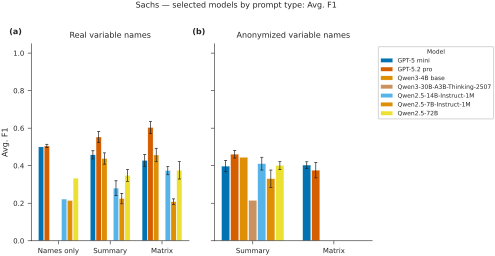

Saved → sachs_selected_models_by_prompt_type_shd


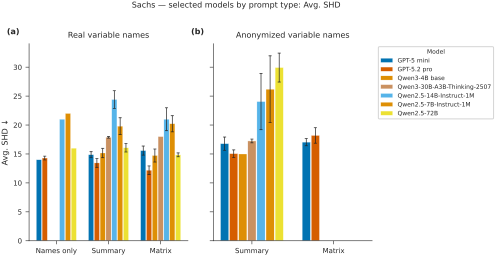

In [29]:
# Selected-model version of the all-model prompt-type plots.
# Edit this list to control which curves appear; names should match display_model.
SELECTED_MODELS = [
    'GPT-5 mini',
    'GPT-5.2 pro',
    'Qwen3-4B base',
    'Qwen3-30B-A3B-Thinking-2507',
    'Qwen2.5-14B-Instruct-1M',
    'Qwen2.5-7B-Instruct-1M',
    'Qwen2.5-72B',

]

selected_model_order = [m for m in SELECTED_MODELS if m in model_order]
missing_selected_models = [m for m in SELECTED_MODELS if m not in model_order]
if missing_selected_models:
    print('Selected models not found:', missing_selected_models)
if not selected_model_order:
    raise ValueError('No selected models were found in model_order.')

real_selected_df = build_plot_df(
    real_src[real_src['display_model'].isin(selected_model_order)],
    real_setting_order,
    selected_model_order,
)
anon_selected_df = build_plot_df(
    anon_src[anon_src['display_model'].isin(selected_model_order)],
    anon_setting_order,
    selected_model_order,
)

# Preserve the same colors used in the all-model figures for easier comparison.
selected_model_color = {m: model_color[m] for m in selected_model_order}
selected_fig_stem = 'sachs_selected_models_by_prompt_type'

# -- Figure 1: Avg. F1 (real | anonymized) ------------------------------------
fig_f1_sel, axes = plt.subplots(1, 2, figsize=(COL2_W, FIG_H * 1.5), sharey=True)

draw_grouped_bars(axes[0], real_selected_df, 'avg_f1', 'f1_se',
                  real_setting_order, selected_model_order, selected_model_color,
                  ylabel='Avg. F1', title='Real variable names',
                  panel_label='(a)', show_legend=True)
axes[0].set_ylim(0, 1.05)

draw_grouped_bars(axes[1], anon_selected_df, 'avg_f1', 'f1_se',
                  anon_setting_order, selected_model_order, selected_model_color,
                  title='Anonymized variable names', panel_label='(b)')
axes[1].set_ylim(0, 1.05)

fig_f1_sel.suptitle('Sachs — selected models by prompt type: Avg. F1',
                    fontsize=FONT_SIZE, y=1.01)
fig_f1_sel.tight_layout()
fig_f1_sel.subplots_adjust(right=0.78)
save_fig(fig_f1_sel, f'{selected_fig_stem}_f1')
plt.show()

# -- Figure 2: Avg. SHD (real | anonymized) -----------------------------------
fig_shd_sel, axes = plt.subplots(1, 2, figsize=(COL2_W, FIG_H * 1.5), sharey=True)

draw_grouped_bars(axes[0], real_selected_df, 'avg_shd', 'shd_se',
                  real_setting_order, selected_model_order, selected_model_color,
                  ylabel='Avg. SHD ↓', title='Real variable names',
                  panel_label='(a)', show_legend=True)

draw_grouped_bars(axes[1], anon_selected_df, 'avg_shd', 'shd_se',
                  anon_setting_order, selected_model_order, selected_model_color,
                  title='Anonymized variable names', panel_label='(b)')

fig_shd_sel.suptitle('Sachs — selected models by prompt type: Avg. SHD',
                     fontsize=FONT_SIZE, y=1.01)
fig_shd_sel.tight_layout()
fig_shd_sel.subplots_adjust(right=0.78)
save_fig(fig_shd_sel, f'{selected_fig_stem}_shd')
plt.show()
